# Beyond the @Mention

# Executive Summary 

This project 'Beyond the @Mention' develops a Natural Language Processing (NLP) solution for classifying Twitter sentiment regarding Apple and Google products. Social media provides real-time customer feedback, making sentiment analysis valuable for product development, customer support, and brand monitoring.

The dataset contains over 9,000 tweets labeled as positive, negative, or neutral sentiment. Data preparation involved duplicate removal, missing value handling, text normalization, tokenization, stopword removal, lemmatization, TF-IDF vectorization, and one-hot encoding of product entities. Class imbalance was addressed using SMOTE.

Three supervised learning models were evaluated: Logistic Regression, Multinomial Naive Bayes, and Random Forest. Model performance was assessed using train-test split validation, confusion matrices, precision, recall, F1-score, and overall accuracy.

Logistic Regression emerged as the strongest overall model after hyperparameter tuning. Explainability techniques including coefficient analysis, SHAP, and LIME were applied to understand how specific words influenced sentiment predictions.

The results demonstrate that NLP can successfully automate large-scale sentiment monitoring and provide actionable business intelligence. However, class imbalance and the limited volume of negative sentiment observations remain key limitations.

## Project Overview

### Context Analysis

In the hyper-competitive tech landscape, public perception is shaped instantly and shifts overnight. During major industry events like product launches, tech workshops or news, social media chatter experiences massive unprecedented spikes. For industry giants like Apple and Google, tracking this raw feedback on realtime is critical for their intelligence algorithms, however it's overwhelming.

The dataset "tweet_product_survey.csv" contains over 9,000 tweets manually annotated by human raters regarding emotions and perceptions directed at brands or products. While human auditing provides high accuracy, it does not scale to handle thousands of incoming mentions per second.

This 'Beyond the @Mention' project aims to build a Proof of Concept (PoC) that Natural Language Processing (NLP) pipeline will develop a text classification model capable of automatically categorizing tweets into distinct sentiment classes: Positive, Negative, or Neutral/No Emotion.

# Business Understanding

The 'Beyond the @Mention' project seeks to Transform massive volumes of unstructured, noisy social media text into structured, actionable business intelligence. These volumes contains critical intelligence that if studied and anlaysed extrapolates customers percetions and emotions that translates into strategies. Specifically, The 'Beyond the @Mention' project seeks to solve the bottleneck of manual brand monitoring by building an automated machine learning engine that can filter out background noise and flag critical customer emotions instantly.


## Why is it important?

This is really important for Apple and Google as it gives them

a) Real-time agility: Social media is a leading indicator of consumer satisfaction or backlash. Waiting weeks for traditional surveys means missing the window to fix an issue instantly or capitalize on a viral trend for marketting.

b) Resource Optimization: Human review of 9,000+ items takes hours or days; an NLP model processes this data in milliseconds, allowing human teams to focus on strategy and mitigation rather than manual reading.

c) Competitive Edge: Since the dataset tracks both Apple and Google ecosystems, this model unlocks the ability to contrast brand sentiment dynamically during major shared tech events.

## How will the predictions be used and by Who?

The predictions will be used by different stakeholders for productive development, address the concerns or ride on trending topics for marketting. 

a) Automated Alert Systems: Negative tweets can be automatically routed to customer service queues or PR with high priority if they exceed a certain confidence threshold.

b) Brand Health Dashboards: Aggregated sentiment scores will populate live corporate dashboards, tracking consumer sentiment shifts week-over-week or during product launches.

c) Feature Request Pipelines: Tweets flagged as "Positive" or "Negative" tied to specific products (e.g., iPad or Android App) will be parsed for keywords to generate automated customer feedback reports for engineering teams.

## Objectives & Data Questions

### Data Analysis Objectives

Project "Beyond the @Mention" seeks to meet the following objectives 
1. Baseline Development: To establish a reliable text preprocessing pipeline.
2. Benchmark Performance: To build an initial TF-IDF vectorizer combined with a linear classifier as a baseline.
3. Iterative Optimization: To evaluate advanced approaches to maximize classification metrics, aiming for an optimal balance between precision (avoiding false alarms) and recall (capturing critical negative feedback).

### Key Business Questions to Answer

1. Class Imbalance: How heavily skewed is the dataset toward neutral chatter (No emotion toward brand or product), and what sampling/loss-weighting strategies will we need to prevent the model from ignoring the critical Negative emotion minority class?

2. Brand Differentiation: Can the model successfully untangle which product/brand a sentiment belongs to when a single tweet mentions both Apple and Google features?

3. Feature Indicators: What are the strongest linguistic predictors that signal a shift from neutral to positive or negative sentiment?

# Data Understanding 

## Loading Libraries and Datasets 

In [1]:
import pandas as pd

#I run the tweet_mention = pd.read_csv('tweet_survey.csv') and UnicodeDecodeError: 'utf-8' codec can't decode byte 0x89 in position 5604: invalid start byte.
#To resolve i forced the UTF-8, and cleaned it. 

#Read the file safely, letting Python handle the encoding bumps
with open('tweet_survey.csv', 'r', encoding='utf-8', errors='replace') as f_in:
    content = f_in.read()

#Save clean csv file that is, true UTF-8 file
with open('tweet_survey_clean.csv', 'w', encoding='utf-8') as f_out:
    f_out.write(content)

#Load the clean file
tweet_mention = pd.read_csv('tweet_survey_clean.csv')

print(tweet_mention.head())

                                          tweet_text  \
0  .@wesley83 I have a 3G iPhone. After 3 hrs twe...   
1  @jessedee Know about @fludapp ? Awesome iPad/i...   
2  @swonderlin Can not wait for #iPad 2 also. The...   
3  @sxsw I hope this year's festival isn't as cra...   
4  @sxtxstate great stuff on Fri #SXSW: Marissa M...   

  emotion_in_tweet_is_directed_at  \
0                          iPhone   
1              iPad or iPhone App   
2                            iPad   
3              iPad or iPhone App   
4                          Google   

  is_there_an_emotion_directed_at_a_brand_or_product  
0                                   Negative emotion  
1                                   Positive emotion  
2                                   Positive emotion  
3                                   Negative emotion  
4                                   Positive emotion  


In [2]:
tweet_mention.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [3]:
tweet_mention.describe

<bound method NDFrame.describe of                                              tweet_text  \
0     .@wesley83 I have a 3G iPhone. After 3 hrs twe...   
1     @jessedee Know about @fludapp ? Awesome iPad/i...   
2     @swonderlin Can not wait for #iPad 2 also. The...   
3     @sxsw I hope this year's festival isn't as cra...   
4     @sxtxstate great stuff on Fri #SXSW: Marissa M...   
...                                                 ...   
9088                      Ipad everywhere. #SXSW {link}   
9089  Wave, buzz... RT @mention We interrupt your re...   
9090  Google's Zeiger, a physician never reported po...   
9091  Some Verizon iPhone customers complained their...   
9092  �ϡ�����_��ʋ�΋�ҋ�������⋁_��������_���RT @mentio...   

     emotion_in_tweet_is_directed_at  \
0                             iPhone   
1                 iPad or iPhone App   
2                               iPad   
3                 iPad or iPhone App   
4                             Google   
...              

In [4]:
tweet_mention.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [5]:
#Missing values 
tweet_mention.isna().sum().sort_values(ascending=False)

emotion_in_tweet_is_directed_at                       5802
tweet_text                                               1
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

In [6]:
#Checking duplicates 
# Returns the total number of identical rows
duplicate_count = tweet_mention.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 22


### Insights from data understanding

1. Dataset contains 9,093 tweets evaluating tech brands and products, 22 exact duplicate rows.
2. The Missing Target Context (The 5,802 Missing Values)

# Exploratory Data Analysis (EDA)

## Data Cleaning 

In [7]:
# Removing Duplicates 
tweet_mention = tweet_mention.drop_duplicates()

# Renaming the columns
tweet_mention = tweet_mention.rename(columns={
    'emotion_in_tweet_is_directed_at': 'The_Product_Entity',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'Tweet_Sentiment_(vibe)', 
    'tweet_text': 'Tweet'})

# Clean the Labels (Updated to use the NEW column name)
# Remove the "I can't tell" sentiment class
tweet_mention = tweet_mention[tweet_mention['Tweet_Sentiment_(vibe)'] != "I can't tell"]

# Map the Target "Missingness" (Updated to use the NEW column name)
# Fill NaN values in The_Product_Entity
tweet_mention['The_Product_Entity'] = tweet_mention['The_Product_Entity'].fillna('Unspecified')

# Dropping Missing Values (Updated to use the NEW column name, though 'Tweet' stayed consistent)
tweet_mention = tweet_mention.dropna(subset=['Tweet'])


In [8]:
tweet_mention.head()

,Tweet,The_Product_Entity,Tweet_Sentiment_(vibe)
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [9]:
#Resetting index 
tweet_mention.reset_index(drop=True, inplace=True)

#Saving clean data set
tweet_mention.to_csv('tweet_mention_cleaned.csv', index=False)

## Tweet Length by Sentiment

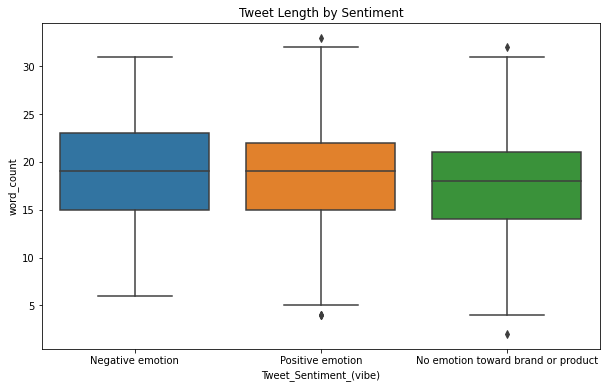

In [11]:
# Checking the twitter length. 
import matplotlib.pyplot as plt
import seaborn as sns

tweet_mention['word_count'] = tweet_mention['Tweet'].fillna('').apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,6))

sns.boxplot(
    data=tweet_mention,
    x='Tweet_Sentiment_(vibe)',
    y='word_count')

plt.title('Tweet Length by Sentiment')
plt.show()

### Tweet Length Insights 

1. The median word count (represented by the center horizontal line inside each box) is nearly identical across all three categories, hovering right around 18 to 19 words per tweet.
2. The "No emotion toward brand or product" category features a slightly lower overall distribution. This suggests that neutral tweets tend to be slightly more concise and consistently contained within a tighter word-count range compared to emotionally charged tweets.

### Word Clouds

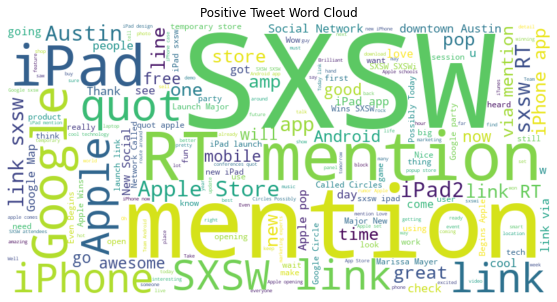

In [18]:
#Most Common Words by Sentiment
#Used the column 'Positive emotion'

from wordcloud import WordCloud

# Added .dropna() to make sure we don't try to read missing values
positive_tweets = tweet_mention[
    tweet_mention['Tweet_Sentiment_(vibe)'] == 'Positive emotion']['Tweet'].dropna()

positive_text = " ".join(positive_tweets)

# Plot the word cloud
if len(positive_text.strip()) > 0:
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white', 
        colormap='viridis').generate(positive_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Positive Tweet Word Cloud')
    plt.show()

### Word Cloud Insights 

1. High Engagement Around Events and Locations (SXSW & Austin): Positive buzz isn't just happening in a vacuum online; it is heavily anchored to the excitement, pop-up events, and real-time experiences shared by attendees at the physical event in Austin.

2. Apple Ecosystem Dominates the Conversation: While "Google" has a clear and noticeable presence, terms representing Apple products heavily dominate the visual landscape. Keywords like "iPad", "iPhone", "iPad2", and "Apple Store" appear much larger and more frequently. This suggests that during this period or event, Apple's hardware launches, features, or store openings generated a higher volume of enthusiastic, positive user praise compared to its competitors.

3. Clear Intentions of Sharing, Community, and Emotion: The vocabulary highlights both the sharing nature of Twitter and explicit positive feelings:

a) Sharing & Virality: High frequencies of "RT" (retweet), "mention", and "link" underscore that positive news and exciting announcements are highly shareable and heavily amplified across social networks.

b) Emotional Signal words: Explicitly positive descriptors like "great", "awesome", "cool", "good", and "free" provide a strong text-based foundation for why the model accurately categorizes these tweets as positive sentiment.

In [19]:
### Word Cloud of Bigrams

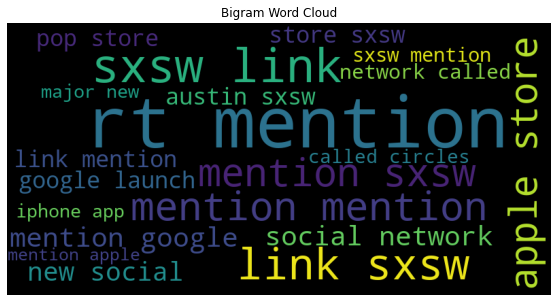

In [20]:
#Word Cloud of Bigrams

from wordcloud import WordCloud

bigram_dict = dict(zip(top20['bigram'],top20['count']))

wordcloud = WordCloud(width=800,height=400).generate_from_frequencies(bigram_dict)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Bigram Word Cloud')
plt.show()

In [21]:
### Top Bigrams

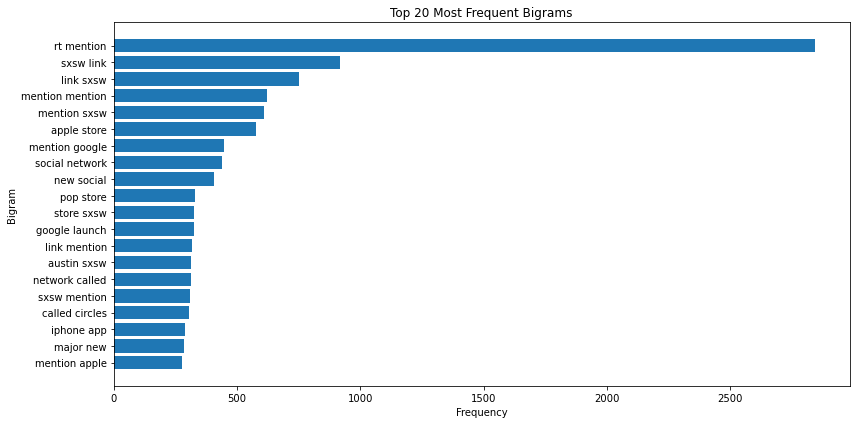

In [22]:
# Top Bigrams
from sklearn.feature_extraction.text import CountVectorizer

bigram = CountVectorizer(ngram_range=(2,2),stop_words='english')

X_bigram = bigram.fit_transform(tweet_mention['Tweet'])

bigram_counts = pd.DataFrame({'bigram': bigram.get_feature_names_out(),'count': X_bigram.sum(axis=0).A1})

bigram_counts.sort_values('count',ascending=False).head(20)

top20 = bigram_counts.sort_values('count',ascending=False).head(20)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    top20['bigram'][::-1],
    top20['count'][::-1])

plt.title('Top 20 Most Frequent Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')

plt.tight_layout()
plt.show()

### Insights from bigrams 

1. Dominant Retweet Noise ("rt mention"): This phrase occurs nearly 3,000 times—tripling any other bigram. It reveals massive content sharing and a high volume of structural Twitter metadata.

2. Heavy Event Hook ("sxsw"): Phrases like "sxsw link", "link sxsw", and "austin sxsw" rank near the top, proving the dataset's context is overwhelmingly anchored to live updates and link-sharing at the SXSW festival.

3. Apple vs. Google Footprints: The text captures distinct brand conversations. Apple trends around physical footprints ("apple store", "pop store"), while Google trends around digital ecosystems ("google launch", "social network", "called circles").

## Data Imbalances 

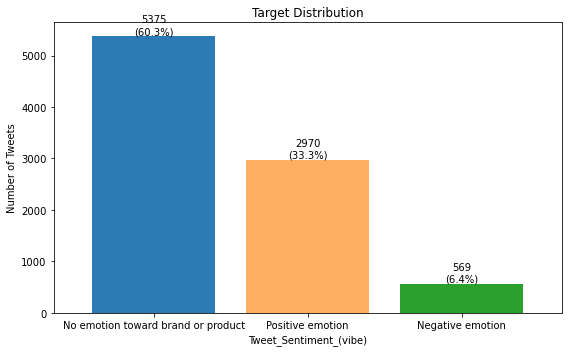

In [24]:
# Checking data imbalances 

import matplotlib.pyplot as plt
import seaborn as sns
# Count observations in each sentiment class
sentiment_counts = tweet_mention['Tweet_Sentiment_(vibe)'].value_counts()

# Percentage distribution
sentiment_percentages = (
    tweet_mention['Tweet_Sentiment_(vibe)']
    .value_counts(normalize=True) * 100)

# Create a summary table
target_distribution = pd.DataFrame({
    'Count': tweet_mention['Tweet_Sentiment_(vibe)'].value_counts(),
    'Percentage (%)': (
        tweet_mention['Tweet_Sentiment_(vibe)']
        .value_counts(normalize=True) * 100).round(2)})


# Visualize the Distribution
sentiment_counts = tweet_mention['Tweet_Sentiment_(vibe)'].value_counts()

# Calculate percentages
sentiment_percentages = (
    sentiment_counts / sentiment_counts.sum() * 100)

# Define the colors
graph_colors = ['#2c7bb6', '#fdae61', '#2ca02c']

# Create the plot and pass the colors list to the 'color' parameter
ax = sentiment_counts.plot(
    kind='bar',
    figsize=(8,5),
    color=graph_colors,
    width=0.8)

# Add count and percentage labels above the bars
for i, count in enumerate(sentiment_counts):
    percentage = sentiment_percentages.iloc[i]

    ax.text(
        i,
        count,
        f'{count}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10)

# Plotting adjustments
plt.title('Target Distribution')
plt.xlabel('Tweet_Sentiment_(vibe)')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)

# Cleans up the padding around the edges
plt.tight_layout()

plt.show()

In [25]:
# Ratio of largest class to smallest class
class_counts = tweet_mention['Tweet_Sentiment_(vibe)'].value_counts()

imbalance_ratio = class_counts.max() / class_counts.min()

print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

Imbalance Ratio: 9.45


## Data Imbalance Insights 

The target variable consists of three sentiment classes: Positive, Negative, and Neutral. 
1. The Positive class accounts for 33.3% of observations.
2. The Negative class accounts for 6.4% %. 
3. The imbalance ratio of 9.45 indicates that the dataset is severely imbalanced (> 5 → Severe imbalance) 

This will be considered during model evaluation by using metrics Precision, Recall, and F1-score rather than relying solely on Accuracy.

## Checking Outliers 

In [48]:
#Checking outliers 
# Character count
tweet_mention['char_count'] = tweet_mention['Tweet'].str.len()

# Word count
tweet_mention['word_count'] = tweet_mention['Tweet'].str.split().str.len()

# Preview
tweet_mention[['Tweet', 'char_count', 'word_count']].head()

,Tweet,char_count,word_count
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,127,23
1,@jessedee Know about @fludapp ? Awesome iPad/i...,139,22
2,@swonderlin Can not wait for #iPad 2 also. The...,79,15
3,@sxsw I hope this year's festival isn't as cra...,82,15
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,131,17


In [49]:
#Statistical Outlier Detection (IQR Method)
Q1 = tweet_mention['word_count'].quantile(0.25)
Q3 = tweet_mention['word_count'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tweet_mention[
    (tweet_mention['word_count'] < lower_bound) |
    (tweet_mention['word_count'] > upper_bound)
]

print("Number of Outlier Tweets:", len(outliers))

#view the outliers 
outliers[['Tweet', 'word_count']].head(20)

Number of Outlier Tweets: 4


,Tweet,word_count
4927,RT @mention,2
5315,RT @mention Apple fans. It looks like there wi...,33
5593,RT @mention every time u hold yur ipad 2 up in...,32
6704,RT @mention Very happy that Discovr has been n...,32


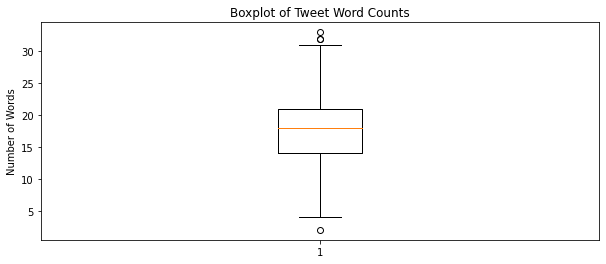

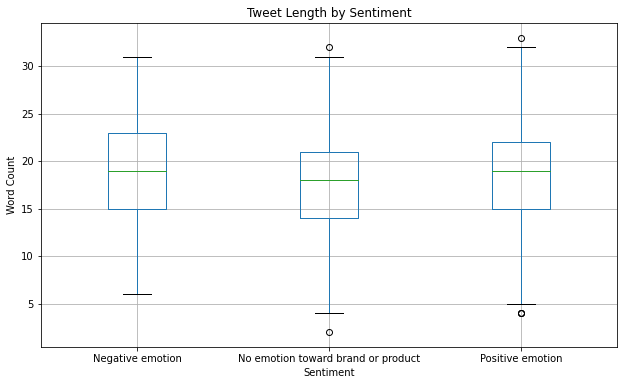

In [50]:
#Plotting the outliers

import matplotlib.pyplot as plt


plt.figure(figsize=(10,4))

plt.boxplot(tweet_mention['word_count'])

plt.title('Boxplot of Tweet Word Counts')
plt.ylabel('Number of Words')

plt.show()

tweet_mention.boxplot(
    column='word_count',
    by='Tweet_Sentiment_(vibe)',
    figsize=(10,6))

plt.title('Tweet Length by Sentiment')
plt.suptitle('')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')

plt.show()

In [51]:
#Identify the Longest Tweets, could often be a spam, Repeated text, URLs, Promotional content, Data quality issues

tweet_mention.nlargest(10,'word_count')[['Tweet', 'word_count']]

,Tweet,word_count
5315,RT @mention Apple fans. It looks like there wi...,33
5593,RT @mention every time u hold yur ipad 2 up in...,32
6704,RT @mention Very happy that Discovr has been n...,32
3022,Say ���Forget You�۝ 2 ur red bar! 1st 5 to mee...,31
3332,#SXSW math: if my flight leaves at 6:45 AM and...,31
5167,RT @mention #sxsw #crm #scrm Join me @mention ...,31
5941,RT @mention I may not have invites to all the ...,31
5945,RT @mention I was going to mock the tech-nerds...,31
6080,RT @mention Just a friendly reminder for #SXSW...,31
6855,RT @mention you know you are on the plane to #...,31


In [52]:
#Checking outliers using TF-IDF-based outlier detection
#Create TF-IDF Matrix 
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000)

X_tfidf = tfidf.fit_transform(tweet_mention['Tweet'])

#Compute Distance from Dataset Center
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

# Compute centroid
centroid = np.asarray(X_tfidf.mean(axis=0))

# Compute distances
distances = cosine_distances(X_tfidf, centroid)

# Flatten to 1D
distances = distances.flatten()

# Add to dataframe
tweet_mention['tfidf_distance'] = distances

#Most Unusual Tweets
outliers = tweet_mention.nlargest( 10,'tfidf_distance')

outliers[['Tweet', 'tfidf_distance']]

,Tweet,tfidf_distance
1232,Listening to some Australian knob (celebrity j...,0.968741
3976,Won 2nd place in Fandango karaoke. 1st prize w...,0.965570
6913,Damn it Google! Your glow-in-the-dark cup leak...,0.964320
3145,A delightful reprieve from #sxsw I spot someth...,0.963008
3433,#SXSWi iPhone gone. Yellow cab minivan 350 if ...,0.962928
3166,Surprising or not surprising that you can type...,0.962829
4158,Mr Heavenly (aka the band w/ Michael Cera) rea...,0.961130
7357,Audience Q: What prototyping tools do you use?...,0.960760
7159,Brought up how Google Maps had rerouted all im...,0.960673
871,"At Red 7, Mist Giant dope! Interviewed Adi fro...",0.959702


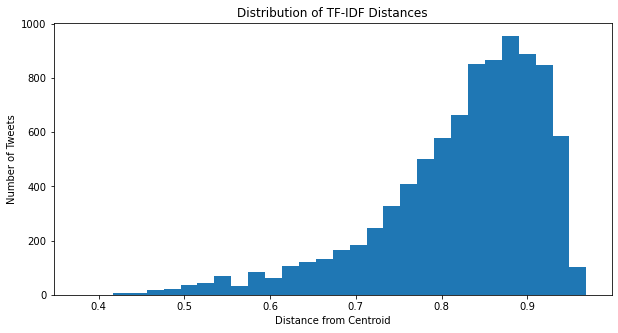

In [53]:
#Plotting the outliers using TF-IDF-based outlier detection

plt.figure(figsize=(10,5))

plt.hist(tweet_mention['tfidf_distance'],bins=30)

plt.title('Distribution of TF-IDF Distances')
plt.xlabel('Distance from Centroid')
plt.ylabel('Number of Tweets')

plt.show()

In [54]:
#Automatically Flag Outliers using TF-IDF-based outlier detection
Q1 = tweet_mention['tfidf_distance'].quantile(0.25)
Q3 = tweet_mention['tfidf_distance'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

tfidf_outliers = tweet_mention[
    tweet_mention['tfidf_distance'] > upper_limit]

print("Number of TF-IDF Outliers:", len(tfidf_outliers))

Number of TF-IDF Outliers: 0


outlier
 1    8826
-1      88
Name: count, dtype: int64


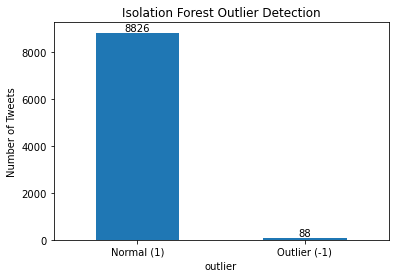

In [55]:
#Checking outliers using Isolation forest 
X_dense = X_tfidf.toarray()

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.01,
    random_state=42)

predictions = iso.fit_predict(X_dense)

tweet_mention['outlier'] = predictions

print(tweet_mention['outlier'].value_counts())

counts = tweet_mention['outlier'].value_counts()

ax = counts.plot(
    kind='bar',
    figsize=(6,4))

for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.xticks(
    [0,1],
    ['Normal (1)', 'Outlier (-1)'],
    rotation=0)

plt.title('Isolation Forest Outlier Detection')
plt.ylabel('Number of Tweets')

plt.show()

## Outlier Detection Insights 

Outlier detection was conducted using two NLP-specific approaches: 
 
1. The TF-IDF method measured the cosine distance of each tweet from the corpus centroid and identified no outliers using the IQR criterion. This suggests that the dataset exhibits relatively consistent vocabulary and thematic content, with no tweets being exceptionally distant from the overall corpus.

2. An Isolation Forest model was also applied to the TF-IDF feature matrix. Using a contamination rate of 1%, the model flagged 88 tweets (0.99% of the dataset) as potential anomalies. These observations represent tweets that are relatively uncommon within the feature space but are not necessarily erroneous. Given the absence of extreme TF-IDF outliers and the small proportion of anomalies detected by Isolation Forest, the dataset appears clean and suitable for sentiment analysis. Consequently, no observations were removed based on the outlier analysis.

## Feature Engineering 

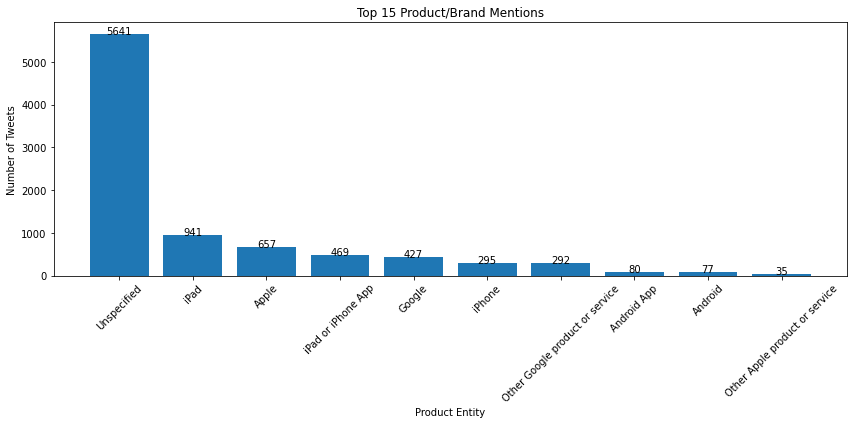

In [33]:
#Reviewing the Features
#Examine Product Entities
tweet_mention['The_Product_Entity'].value_counts().head(20)

#Visualize Top Product Mentions
top_products = (tweet_mention['The_Product_Entity'].value_counts().head(15))

plt.figure(figsize=(12,6))

bars = plt.bar(top_products.index,top_products.values)

#Add counts
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center')

plt.title('Top 15 Product/Brand Mentions')
plt.xlabel('Product Entity')
plt.ylabel('Number of Tweets')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### TF-IDF Feature Importance

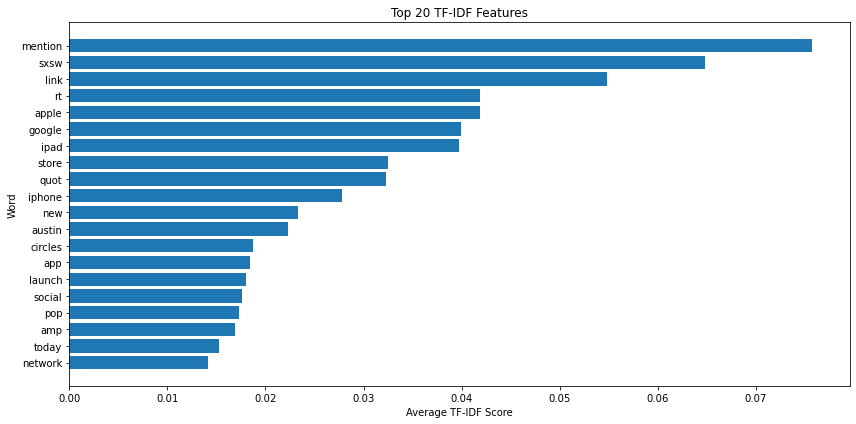

In [34]:
# Extract feature names
feature_names = tfidf.get_feature_names_out()

# Calculate average TF-IDF score for each feature
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()

# Create DataFrame
tfidf_df = pd.DataFrame({
    'feature': feature_names,
    'avg_tfidf_score': mean_tfidf})

# Sort descending
top_features = tfidf_df.sort_values(
    by='avg_tfidf_score',
    ascending=False)

top_features.head(20)

import matplotlib.pyplot as plt

top20 = top_features.head(20)

plt.figure(figsize=(12,6))

plt.barh(
    top20['feature'][::-1],
    top20['avg_tfidf_score'][::-1])

plt.title('Top 20 TF-IDF Features')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Word')

plt.tight_layout()
plt.show()

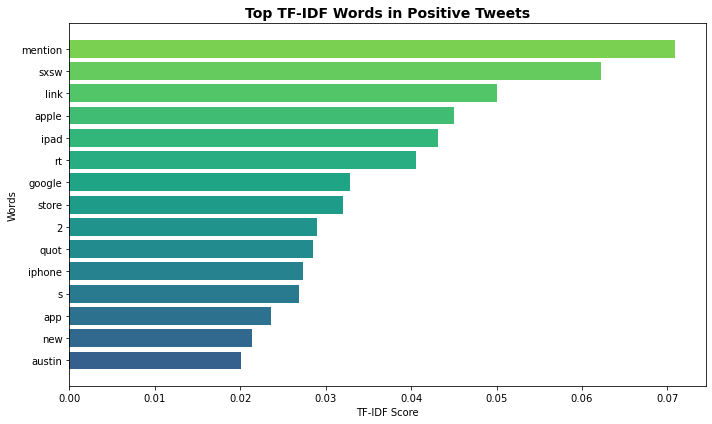

In [49]:
#TF-IDF by Sentiment- Positive Sentiments 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Isolate the positive emotion text and drop empty rows
positive_tweets = tweet_mention[tweet_mention['Tweet_Sentiment_(vibe)'] == 'Positive emotion']['Tweet'].dropna()

#Adjust TF-IDF parameters to be more forgiving
# token_pattern=r"(?u)\b\w+\b" ensures short 1-2 letter words aren't ignored
tfidf = TfidfVectorizer(stop_words='english', token_pattern=r"(?u)\b\w+\b",  min_df=1,lowercase=True)

#Fit and transform the text safely
try:
    X_pos = tfidf.fit_transform(positive_tweets)
    pos_scores = np.asarray(X_pos.mean(axis=0)).flatten()

#Create the summary DataFrame
    pos_df = pd.DataFrame({'word': tfidf.get_feature_names_out(),'score': pos_scores})

#Top 15 words
    top_positive_words = pos_df.sort_values('score', ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(top_positive_words)))

    plt.barh(top_positive_words['word'][::-1],top_positive_words['score'][::-1],color=colors)

    plt.title('Top TF-IDF Words in Positive Tweets', fontsize=14, fontweight='bold')
    plt.xlabel('TF-IDF Score')
    plt.ylabel('Words')
    plt.tight_layout()
    plt.show()

except ValueError as e:
    print(f"Error: {e}")

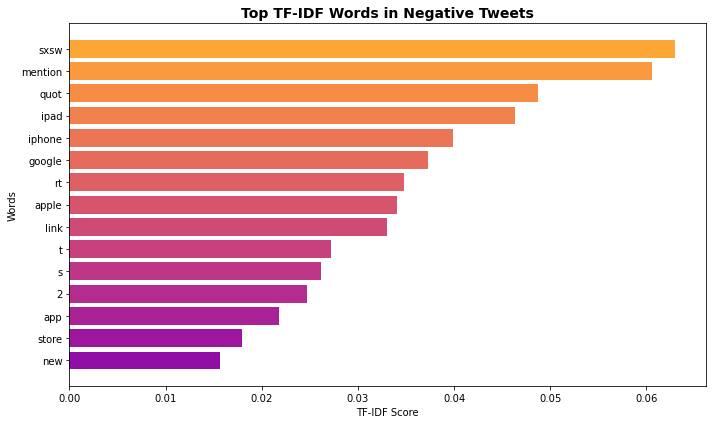

In [35]:
#TF-IDF by Sentiment- Positive Sentiments 
# Isolate the negative emotion text and drop empty rows
negative_tweets = tweet_mention[
    tweet_mention['Tweet_Sentiment_(vibe)'] == 'Negative emotion']['Tweet'].dropna()

#TF-IDF parameters to capture all available words safely
tfidf_neg = TfidfVectorizer(stop_words='english', token_pattern=r"(?u)\b\w+\b",  min_df=1,lowercase=True)

#Fit and transform the negative text safely
try:
    X_neg = tfidf_neg.fit_transform(negative_tweets)
    neg_scores = np.asarray(X_neg.mean(axis=0)).flatten()

#Create the summary DataFrame
    neg_df = pd.DataFrame({
        'word': tfidf_neg.get_feature_names_out(),
        'score': neg_scores})

#Get top 15 words
    top_negative_words = neg_df.sort_values('score', ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    colors = plt.cm.plasma(np.linspace(0.3, 0.8, len(top_negative_words)))

    plt.barh(top_negative_words['word'][::-1], top_negative_words['score'][::-1],color=colors)

    plt.title('Top TF-IDF Words in Negative Tweets', fontsize=14, fontweight='bold')
    plt.xlabel('TF-IDF Score')
    plt.ylabel('Words')
    plt.tight_layout()
    plt.show()

except ValueError as e:
    print(f"Error: {e}")

[nltk_data] Downloading package stopwords to /Users/jane/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


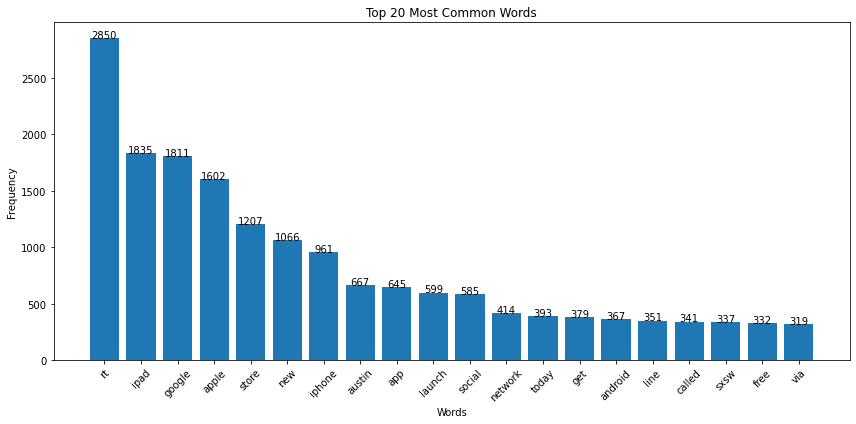

In [36]:
#Most Common words 
#Create corpus 
text = " ".join(tweet_mention['Tweet'].astype(str))

#Tokenize and Remove Stopwords
from nltk.corpus import stopwords
from collections import Counter
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

words = [
    word.lower()
    for word in text.split()
    if word.isalpha()]

words_clean = [
    word
    for word in words
    if word not in stop_words]

#Count Frequencies
word_freq = Counter(words_clean)

top_words = word_freq.most_common(20)

#Visualize Most Common Words

import matplotlib.pyplot as plt

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(12,6))

bars = plt.bar(words, counts)

# Add counts
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center')

plt.title('Top 20 Most Common Words')
plt.xlabel('Words')
plt.ylabel('Frequency')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [37]:
#Most Common Words by Sentiment
#Positive Tweets 
positive_tweets = " ".join(
    tweet_mention[
        tweet_mention['Tweet_Sentiment_(vibe)'] == 'positive']['Tweet'])

#Negative Tweets 
negative_tweets = " ".join(
    tweet_mention[
        tweet_mention['Tweet_Sentiment_(vibe)'] == 'negative']['Tweet'])

#Neutral Tweets 
neutral_tweets = " ".join(
    tweet_mention[
        tweet_mention['Tweet_Sentiment_(vibe)'] == 'neutral']['Tweet'])

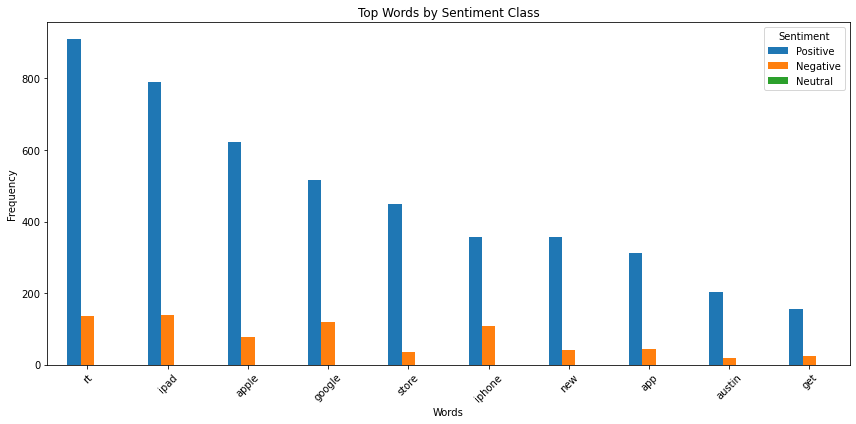

In [38]:
#Sentiment Word Comparison Chart
from collections import Counter
from nltk.corpus import stopwords
import pandas as pd
import matplotlib.pyplot as plt

stop_words = set(stopwords.words('english'))

def get_words(text_series):
    text = " ".join(text_series.astype(str))

    words = [
        w.lower()
        for w in text.split()
        if w.isalpha() and w.lower() not in stop_words]

    return Counter(words)

#Build word frequency dictionaries
positive_counts = get_words(
    tweet_mention[tweet_mention['Tweet_Sentiment_(vibe)'] == 'Positive emotion']['Tweet'])

negative_counts = get_words(
    tweet_mention[tweet_mention['Tweet_Sentiment_(vibe)'] == 'Negative emotion']['Tweet'])

neutral_counts = get_words(
    tweet_mention[tweet_mention['Tweet_Sentiment_(vibe)'] == 'Neutral emotion']['Tweet'])

#Top Words Across All Sentiments
top_words = (positive_counts + negative_counts + neutral_counts)

top_words = [word for word, count in top_words.most_common(10)]

#Comparison DataFrame
comparison_df = pd.DataFrame({
    "Positive": [positive_counts.get(w, 0) for w in top_words],
    "Negative": [negative_counts.get(w, 0) for w in top_words],
    "Neutral": [neutral_counts.get(w, 0) for w in top_words]}, index=top_words)

#Visualize 
ax = comparison_df.plot(
    kind='bar',
    figsize=(12,6))

plt.title('Top Words by Sentiment Class')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.legend(title='Sentiment')

plt.tight_layout()
plt.show()

### Insights from Most Common words 

The most frequent words across all sentiment classes were product and brand names rather than emotional terms. This suggests that additional preprocessing steps such as stopword expansion, lemmatization, and TF-IDF weighting may be necessary to reduce the influence of common product identifiers and enhance sentiment-specific signal extraction.

# Data Preparation

## Data Preprocessing

In [44]:
#Data Preprocessing 
from sklearn.preprocessing import LabelEncoder
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Initialize processors correctly
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True)  # <--- Change this line
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
label_encoder = LabelEncoder()

# Fit and transform the target column
tweet_mention['Target_Encoded'] = label_encoder.fit_transform(tweet_mention['Tweet_Sentiment_(vibe)'])

# Ensure negation terms like "not" or "no" aren't lost, as they heavily influence tech sentiment
words_to_keep = {'not', 'no', 'never', "isn't", "can't", "couldn't"}
stop_words = stop_words - words_to_keep

def full_nlp_cleaner(text):
    if not isinstance(text, str):
        return ""
    
#Strip URLs / Links
    text = re.sub(r'https?://\S+|www\.\S+|\{link\}', '', text)
    
#Strip Hashtag symbols (#SXSW -> SXSW) and mentions (@mention)
    text = re.sub(r'#|@mention|@\S+', '', text)
    
#Strip extra symbols, formatting text, or numerical characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
#Tokenization & Lowercasing
    tokens = tokenizer.tokenize(text.lower())
    
#Stop Word Filters & Lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(token) 
        for token in tokens 
        if token not in stop_words]
    
#Re-join tokens into a single clean string statement
    return " ".join(cleaned_tokens)

# Apply this to your fresh DataFrame
tweet_mention['Cleaned_Tweet_Final'] = tweet_mention['Tweet'].apply(full_nlp_cleaner)

In [45]:
#Checking the dataset after preprocessing 
tweet_mention.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914 entries, 0 to 8913
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Tweet                   8914 non-null   object 
 1   The_Product_Entity      8914 non-null   object 
 2   Tweet_Sentiment_(vibe)  8914 non-null   object 
 3   word_count              8914 non-null   int64  
 4   char_count              8914 non-null   int64  
 5   tfidf_distance          8914 non-null   float64
 6   Target_Encoded          8914 non-null   int64  
 7   Cleaned_Tweet_Final     8914 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 557.2+ KB


## Defining text and target feature

In [58]:
#Final Dataset preperation before modelling
import pandas as pd
from sklearn.model_selection import train_test_split

#One Hot Encode The_Product_Entity as a predictor, encode it into 1s and 0s
product_dummies = pd.get_dummies(tweet_mention['The_Product_Entity'], prefix='prod', drop_first=True)

# Checking engineered numeric columns alongside the new dummy variables
numerical_features = tweet_mention[['char_count', 'word_count', 'tfidf_distance', 'outlier']]
X_numeric = tweet_mention[['char_count','word_count']]

# Ensure all column names in X_numeric are strings
X_numeric.columns = X_numeric.columns.astype(str)

# Defining text and target feature
X_text = tweet_mention['Cleaned_Tweet_Final'] 
y = tweet_mention['Target_Encoded'] 

#Instead of single X we have X_text and X_numeric before splitting. This is because data leakage in text processing

#Checking the numericals 

print(f"Text feature shape: {X_text.shape}")
print(f"Numeric metadata features shape: {X_numeric.shape}")
print(f"Target variable shape: {y.shape}")

Text feature shape: (8914,)
Numeric metadata features shape: (8914, 2)
Target variable shape: (8914,)


## Validation Strategy

A stratified train-test split was used to ensure that the distribution of positive, negative, and neutral sentiment remained consistent across both training and testing datasets. This approach provides an unbiased estimate of model performance on unseen tweets while preventing information leakage during training.

## Data Splitting 

In [59]:
#Data Splitting 
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, \
X_num_train, X_num_test, \
y_train, y_test = train_test_split(
    X_text,
    X_numeric,
    y,
    test_size=0.2,
    random_state=7,
    stratify=y)

print("X_text_train:", X_text_train.shape)
print("X_text_test:", X_text_test.shape)

print("X_num_train:", X_num_train.shape)
print("X_num_test:", X_num_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_text_train: (7131,)
X_text_test: (1783,)
X_num_train: (7131, 2)
X_num_test: (1783, 2)
y_train: (7131,)
y_test: (1783,)


## Data Vectorization 

In [60]:
#Vectorization 
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2))

X_text_train_tfidf = tfidf.fit_transform(X_text_train)

X_text_test_tfidf = tfidf.transform(X_text_test)

#Combine Numerics 
from scipy.sparse import hstack

X_train_final = hstack([
    X_text_train_tfidf,
    X_num_train.values])

X_test_final = hstack([
    X_text_test_tfidf,
    X_num_test.values])

## SMOTE Data Balancing 

In [61]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
# Using the same random_state for consistency
smote = SMOTE(random_state=7)

# Resample ONLY the training data
# This takes your stacked text+numeric features and balances the target classes
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

# 3. Print the new shapes to verify it worked
print("Before SMOTE - X_train_final shape:", X_train_final.shape)
print("Before SMOTE - y_train distribution:\n", y_train.value_counts())
print("\n" + "="*40 + "\n")
print("After SMOTE - X_train_resampled shape:", X_train_resampled.shape)
print("After SMOTE - y_train_resampled distribution:\n", y_train_resampled.value_counts())

Before SMOTE - X_train_final shape: (7131, 5002)
Before SMOTE - y_train distribution:
 Target_Encoded
1    4300
2    2376
0     455
Name: count, dtype: int64


After SMOTE - X_train_resampled shape: (12900, 5002)
After SMOTE - y_train_resampled distribution:
 Target_Encoded
1    4300
2    4300
0    4300
Name: count, dtype: int64


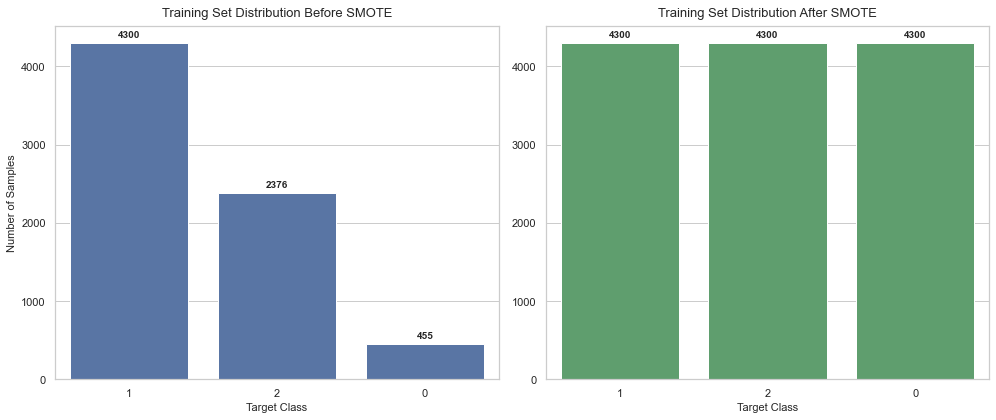

In [62]:
#Visualizing SMOTE

import seaborn as sns

# Set clean style
sns.set_theme(style="whitegrid")

# Create a DataFrame for plotting convenience
before_counts = y_train.value_counts().reset_index()
before_counts.columns = ['Class', 'Count']
before_counts['Status'] = 'Before SMOTE (Imbalanced)'

after_counts = y_train_resampled.value_counts().reset_index()
after_counts.columns = ['Class', 'Count']
after_counts['Status'] = 'After SMOTE (Balanced)'

# Combine data into one dataframe
plot_df = pd.concat([before_counts, after_counts])

# Map class numbers to names if needed (e.g., 0, 1, 2)
# If your classes are integers, this ensures they display clearly
plot_df['Class'] = plot_df['Class'].astype(str)

# Setup side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Plot 1: Before SMOTE
sns.barplot(
    data=plot_df[plot_df['Status'] == 'Before SMOTE (Imbalanced)'],
    x='Class', y='Count', color='#4C72B0', ax=axes[0])
axes[0].set_title("Training Set Distribution Before SMOTE", fontsize=13, pad=10)
axes[0].set_xlabel("Target Class", fontsize=11)
axes[0].set_ylabel("Number of Samples", fontsize=11)

# Add value labels on top of bars
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, weight='bold')

# Plot 2: After SMOTE
sns.barplot(
    data=plot_df[plot_df['Status'] == 'After SMOTE (Balanced)'],
    x='Class', y='Count', color='#55A868', ax=axes[1])
axes[1].set_title("Training Set Distribution After SMOTE", fontsize=13, pad=10)
axes[1].set_xlabel("Target Class", fontsize=11)
axes[1].set_ylabel("", fontsize=11) # Hide label since it shares context

# Add value labels on top of bars
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, weight='bold')

# Adjust layout and show
plt.tight_layout()
plt.show()

### Insights from SMOTE

The training dataset exhibited substantial class imbalance prior to resampling, with Class 1 accounting for 60.3% of observations, Class 2 for 33.3%, and Class 0 for only 6.4%. Such imbalance can bias machine learning models toward majority classes and reduce predictive performance on minority classes. To address this issue, the Synthetic Minority Oversampling Technique (SMOTE) was applied to the training data. Following resampling, all classes contained 4,300 observations, resulting in a perfectly balanced dataset of 12,900 samples. This increased the training set size by approximately 81% and provided the model with sufficient representation from previously underrepresented classes, thereby improving its ability to learn balanced decision boundaries and enhancing minority-class prediction performance.

# Data Modelling 

## Base Model: Linear Regression 

/usr/local/Caskroom/miniconda/base/envs/learn-env/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression Accuracy: 0.6568
              precision    recall  f1-score   support

           0       0.33      0.57      0.42       114
           1       0.77      0.70      0.73      1075
           2       0.58      0.60      0.59       594

    accuracy                           0.66      1783
   macro avg       0.56      0.62      0.58      1783
weighted avg       0.68      0.66      0.66      1783



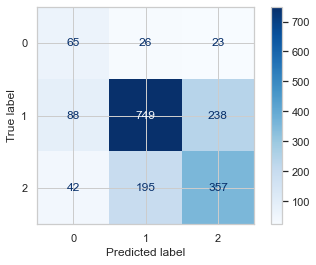

In [65]:
#Base Model 
#Linear Regression 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score


model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced')

model.fit(X_train_resampled, y_train_resampled)

#Make Predictions
y_pred = model.predict(X_test_final)

#Check Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"LogisticRegression Accuracy: {accuracy:.4f}")

print(classification_report(y_test, y_pred))

#CM Visual 
lr_cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues')

plt.show()

## Model 2: Multinomial Naive Bayes Model 

Naive Bayes Accuracy: 0.5687

Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.68      0.35       114
           1       0.78      0.53      0.63      1075
           2       0.50      0.61      0.55       594

    accuracy                           0.57      1783
   macro avg       0.51      0.61      0.51      1783
weighted avg       0.65      0.57      0.59      1783



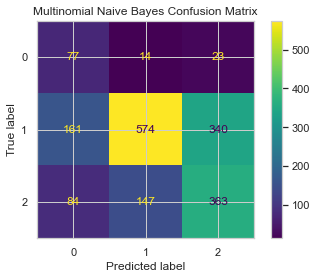

In [66]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Train model and fit model 

nb_model = MultinomialNB()

nb_model.fit(X_train_resampled, y_train_resampled)


# Predictions
y_pred_nb = nb_model.predict(X_test_final)

# Accuracy Score

nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

#Confusion matrix 
mnb_cm = confusion_matrix(y_test, y_pred_nb)

#CM Visual 
disp = ConfusionMatrixDisplay(
    confusion_matrix=mnb_cm)

disp.plot()

plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.show()



## Model 3: Random Forest

Random Forest Accuracy: 0.6859

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.30      0.40       114
           1       0.71      0.85      0.77      1075
           2       0.63      0.47      0.54       594

    accuracy                           0.69      1783
   macro avg       0.64      0.54      0.57      1783
weighted avg       0.68      0.69      0.67      1783



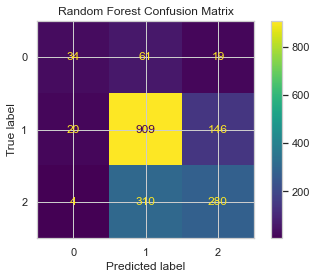

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Train and fit model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_rf = rf_model.predict(X_test_final)

# Accuracy Score
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)

# Confusion Matrix Visualization

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

## Model Comparison 

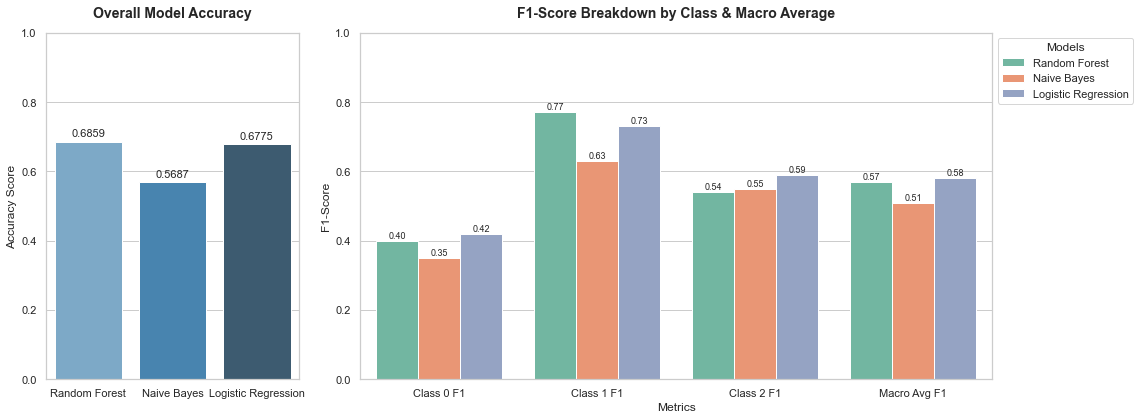

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Prepare the data from your classification reports
models = ["Random Forest", "Naive Bayes", "Logistic Regression"]
accuracies = [0.6859, 0.5687, 0.6775]

# Extracting F1-scores for each class
f1_class_0 = [0.40, 0.35, 0.42]
f1_class_1 = [0.77, 0.63, 0.73]
f1_class_2 = [0.54, 0.55, 0.59]
macro_avg = [0.57, 0.51, 0.58]

# Create a DataFrame for easy plotting with Seaborn
data = {
    "Model": models * 4,
    "Metric": ["Class 0 F1"] * 3
    + ["Class 1 F1"] * 3
    + ["Class 2 F1"] * 3
    + ["Macro Avg F1"] * 3,
    "Score": f1_class_0 + f1_class_1 + f1_class_2 + macro_avg,}
df_metrics = pd.DataFrame(data)

#Set up the plot layout (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 2.5]})
sns.set_theme(style="whitegrid")

#Overall Accuracy Comparison ---
sns.barplot(x=models, y=accuracies, ax=axes[0], palette="Blues_d")
axes[0].set_title("Overall Model Accuracy", fontsize=14, fontweight="bold", pad=15)
axes[0].set_ylabel("Accuracy Score", fontsize=12)
axes[0].set_ylim(0, 1.0)

# Add value labels on top of the accuracy bars
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.4f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=11,)

#Detailed F1-Score Breakdown per Class ---
sns.barplot(
    x="Metric", y="Score", hue="Model", data=df_metrics, ax=axes[1], palette="Set2")
axes[1].set_title(
    "F1-Score Breakdown by Class & Macro Average",
    fontsize=14,
    fontweight="bold",
    pad=15,)
axes[1].set_ylabel("F1-Score", fontsize=12)
axes[1].set_xlabel("Metrics", fontsize=12)
axes[1].set_ylim(0, 1.0)
axes[1].legend(title="Models", loc="upper left", bbox_to_anchor=(1, 1))

# Add value labels to the breakdown bars
for p in axes[1].patches:
    if p.get_height() > 0:  # Avoid annotating empty/missing bars
        axes[1].annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=9,)

plt.tight_layout()
plt.show()

### Insights from Model Comparison

1. The "Imbalanced Test Set" Trap: Even though SMOTE balanced instances, there still exists highly imbalanced (Class 1 has 1,075 instances, while Class 0 only has 114).

2. Class 0 (The Minority Class) remains a struggle: Despite SMOTE, Class 0 F1-scores are universally the lowest across all models (ranging from 0.35 to 0.42).Logistic Regression actually achieved the highest F1-score here (0.42), driven by a solid recall of 0.57.

3. Random Forest vs. Logistic Regression: Random Forest maximizes performance on the majority class (Class 1 F1 = 0.77), which boosts its overall accuracy to 0.6859. Logistic Regression is much more mathematically stable across the board. It beats or matches Random Forest on Class 0 and Class 2 metrics, resulting in a higher overall Macro Average F1-score (0.58).

4. The Best Model for Tuning: Logistic Regression becasue, it handles Class 0 significantly better than Random Forest without sacrificing too much performance on Class 1. Higher Macro Average and lots of room for Optimization.

## Hyperparameter Tuning for Logistic Regression

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

#Final Logistic Regression model for tuning 
model = LogisticRegression(max_iter=1000,class_weight='balanced')

model.fit(X_train_resampled, y_train_resampled)

# Parameter Grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']}

# Base Model
lr = LogisticRegression(
    max_iter=2000,
    random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1)

# Fit Grid Search
grid_search.fit(X_train_resampled, y_train_resampled)

# Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

# Best Model
best_lr = grid_search.best_estimator_

# Predictions
y_pred_tuned = best_lr.predict(X_test_final)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'C': 100, 'class_weight': None, 'solver': 'liblinear'}

Best Cross Validation Score:
0.8417921907164001


### ROC Curves 

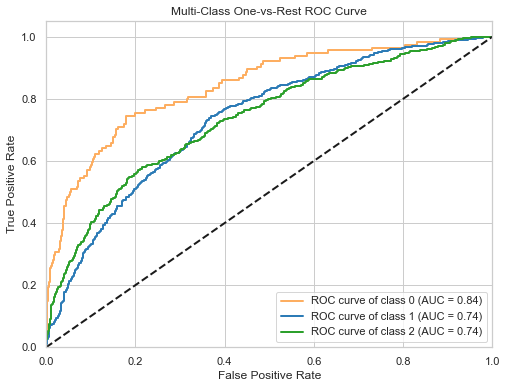

In [80]:
#ROC Curve 
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

#Get unique classes from your target
classes = np.unique(y_test)

#Binarize the output classes for evaluation
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

#Get predicted probabilities from your best Logistic Regression model
y_score = best_lr.predict_proba(X_test_final)

#Plot an ROC curve for each class
plt.figure(figsize=(8, 6))
colors = ['#fdae61', '#2c7bb6', '#2ca02c'] # Matches your notebook's color theme!

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(
        fpr, tpr, 
        color=colors[i % len(colors)],
        lw=2, 
        label=f'ROC curve of class {class_name} (AUC = {roc_auc:.2f})')

#Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class One-vs-Rest ROC Curve')
plt.legend(loc="lower right")
plt.show()

### ROC Curve Insights

1. Strong Overall Class Discrimination: The model demonstrates solid predictive power across all three categories, as every curve arches well above the diagonal dashed line (which represents random guessing).

2. Class 0 exhibits the highest predictive performance: With an AUC of 0.84, the orange curve for Class 0 sits closest to the top-left corner of the plot. This tells us the model is exceptionally good at separating Class 0 from the other categories, achieving a high True Positive Rate while maintaining a very low False Positive Rate.

3. Identical overall performance for Classes 1 and 2: The blue curve (Class 1) and the green curve (Class 2) both achieve an AUC of 0.74. While their overall geometric areas under the curve are identical, they follow slightly different trajectories across the threshold spectrum, meaning the model makes distinct trade-offs when classifying each of them.

4. Distinct trade-off variations between Class 1 and Class 2: 
a) Early Thresholds (FPR < 0.3): The green curve (Class 2) climbs faster than the blue curve (Class 1), indicating that the model is better at capturing true positives for Class 2 at strict, low-false-positive thresholds.
b) Later Thresholds (FPR > 0.3): The blue curve (Class 1) overtakes the green curve, showing that if you allow a moderate amount of false positives, the model achieves a higher sensitivity/recall for Class 1 than for Class 2.

## Model Evaluation

Tuned Accuracy: 0.6685

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.46      0.43       114
           1       0.75      0.74      0.75      1075
           2       0.58      0.58      0.58       594

    accuracy                           0.67      1783
   macro avg       0.58      0.59      0.59      1783
weighted avg       0.67      0.67      0.67      1783


Confusion Matrix:


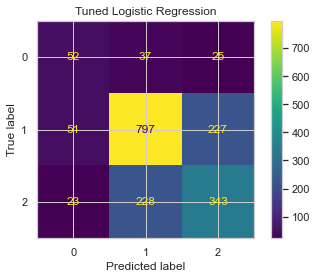

In [82]:
# Accuracy
tuned_accuracy = accuracy_score(y_test,y_pred_tuned)

print(f"Tuned Accuracy: {tuned_accuracy:.4f}")

# Classification Report

print("\nClassification Report:")
print(classification_report(y_test,y_pred_tuned))

# Confusion Matrix
tuned_cm = confusion_matrix(y_test,y_pred_tuned)

print("\nConfusion Matrix:")

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm)

disp.plot()

plt.title("Tuned Logistic Regression")
plt.show()

### Insights from Tuned Logistic Regression and Confusion Matrix

1. The Trade-Off (Accuracy vs. Balance): Raw accuracy dropped slightly from 67.75% to 66.85% which is a win because when overall accuracy goes down when the model stops blindly guessing the majority class and starts paying attention to the minority classes.

2. Macro F1-Score Improvement: Macro Average F1-score increased from 0.58 to 0.59 confirming the model is better across all three categories rather than just getting lucky on the dominant one.

3. Class 0 (Minority Class) Lift: The tuning successfully lifted Class 0's F1-score from 0.42 to 0.43 and precision jumped significantly from 0.33 to 0.41.

4. Class 1 & 2 Stabilization: Class 1 (Majority) stabilized with balanced precision (0.75) and recall (0.74). Class 2 achieved a perfectly symmetric precision and recall of 0.58.

Confusion Matrix 
1. Diagonal Dominance (True Positives): The main diagonal contains your correct predictions: 52 (Class 0), 797 (Class 1), and 343 (Class 2). Indicating the tuned model clearly handles Class 1 exceptionally well.

2. The Class 0 Reality Check: Out of 114 actual Class 0 instances, the model correctly found 52. However, it misclassified 37 of them as Class 1 and 25 of them as Class 2.

3. The Main Blunder Zone (Class 1 vs. Class 2): Biggest area of confusion is between Classes 1 and 2:

# Model Explainability

In [83]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_text_train)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_tfidf, y_train)

#Initialize the model
model = LogisticRegression(max_iter=1000)

#You must fit the model to your data before coef_ exists!
# Replace X_train_tfidf and y_train with your actual variable names
model.fit(X_train_tfidf, y_train)

#Extract feature names from your fitted TF-IDF vectorizer
feature_names = np.array(tfidf.get_feature_names_out())

#Changed 'lr.coef_[0]' to 'model.coef_[0]' to match your variable name
coefficients = model.coef_[0]

# Top positive words (largest coefficients)
top_positive_idx = np.argsort(coefficients)[-20:]

# Top negative words (smallest/most negative coefficients)
top_negative_idx = np.argsort(coefficients)[:20]

print("Top Positive Words")
print("-"*30)
# Reverse positive index so the absolute highest is printed first
for word, coef in zip(feature_names[top_positive_idx][::-1],
                      coefficients[top_positive_idx][::-1]):
    print(f"{word}: {coef:.4f}")

print("\nTop Negative Words")
print("-"*30)
for word, coef in zip(feature_names[top_negative_idx],
                      coefficients[top_negative_idx]):
    print(f"{word}: {coef:.4f}")

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


Top Positive Words
------------------------------
fail: 2.4310
suck: 2.3798
not: 1.9478
hate: 1.9122
button: 1.7707
headache: 1.7039
fascist: 1.5384
isnt: 1.3507
another: 1.3299
fade: 1.3177
long: 1.2963
instead: 1.2673
money: 1.2017
iphone: 1.1686
nothing: 1.1597
design: 1.1286
battery: 1.0989
didnt: 1.0700
many: 1.0689
fuck: 1.0321

Top Negative Words
------------------------------
sxsw: -1.4849
free: -1.4779
amp: -1.2933
party: -1.2834
store: -1.1112
rt: -1.0397
mobile: -1.0059
win: -0.9713
case: -0.9469
austin: -0.9330
music: -0.8289
android: -0.8018
video: -0.7954
check: -0.7641
downtown: -0.7597
winning: -0.7473
event: -0.7290
fun: -0.7041
rumor: -0.6973
today: -0.6957


In [84]:
coef_df = pd.DataFrame({
    'word': feature_names,
    'coefficient': coefficients})

# Positive words
positive_words = coef_df.sort_values(
    by='coefficient',
    ascending=False
).head(20)

# Negative words
negative_words = coef_df.sort_values(
    by='coefficient',
    ascending=True
).head(20)

print("Most Positive Words")
display(positive_words)

print("Most Negative Words")
display(negative_words)

Most Positive Words


,word,coefficient
1347,fail,2.430998
4066,suck,2.379842
2581,not,1.947770
1738,hate,1.912152
533,button,1.770743
1748,headache,1.703929
1366,fascist,1.538378
2020,isnt,1.350699
163,another,1.329948
1345,fade,1.317734


Most Negative Words


,word,coefficient
4112,sxsw,-1.484900
1486,free,-1.477887
136,amp,-1.293348
2713,party,-1.283389
4025,store,-1.111169
3535,rt,-1.039727
2445,mobile,-1.005926
4764,win,-0.971333
585,case,-0.946877
260,austin,-0.932990


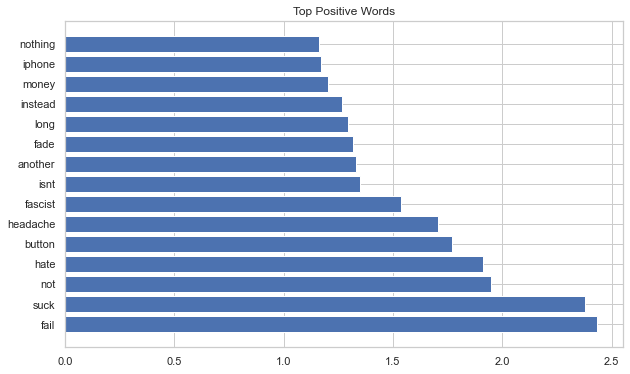

In [85]:
#Visualization
import matplotlib.pyplot as plt

top_pos = coef_df.sort_values(
    by='coefficient',
    ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(top_pos['word'], top_pos['coefficient'])
plt.title('Top Positive Words')
plt.show()

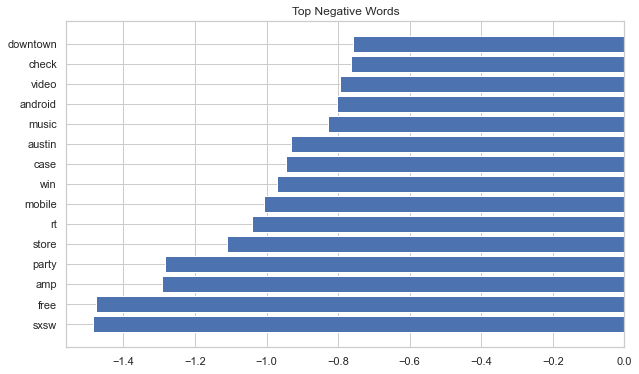

In [86]:
#Negative words:

top_neg = coef_df.sort_values(
    by='coefficient').head(15)

plt.figure(figsize=(10,6))
plt.barh(top_neg['word'], top_neg['coefficient'])
plt.title('Top Negative Words')
plt.show()

## SHAP Explainability

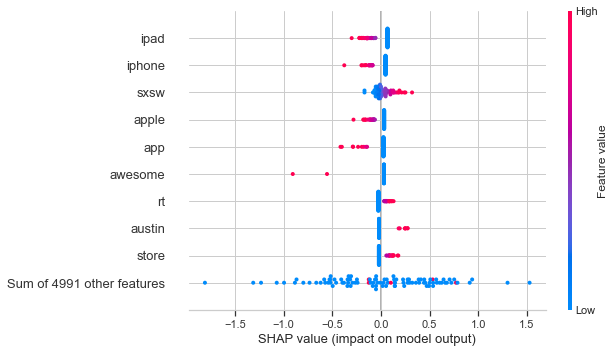

In [87]:
#SHAP Explainability
import shap

# 1. Initialize the explainer
explainer = shap.Explainer(
    lr, 
    X_train_tfidf, 
    feature_names=tfidf.get_feature_names_out()
)

# 2. Generate the SHAP values (converting to array helps SHAP handle sparse TF-IDF text matrices)
shap_values = explainer(X_train_tfidf[:100].toarray())

# 3. FIX: Slice the SHAP values to look at Class 1 (the positive class)
# The dimensions are [instances, features, classes]. 
# [:, :, 1] extracts all instances and all features for Class 1.
shap_values_positive_class = shap_values[:, :, 1]

# 4. Plot the beeswarm
shap.plots.beeswarm(shap_values_positive_class)

### SHAP Insights 

1. Words like "ipad", "iphone", "apple", and "app" have a strong negative impact, when they appear in a text, it heavily drives the model's prediction toward Class 0.Conversely, the blue vertical wall at 0.0 means their absence has zero effect.

2. Words like "awesome", "sxsw", "austin", and "store" push predictions toward Class 1: Look at "awesome": You can see red dots stretching far to the left and dense cluster of pink/red dots for "sxsw", "austin", and "store" sitting to the right of 0.0. When a post mentions "sxsw" or "austin", it actively pushes the model to predict Class 1.

3. "rt" (Retweet): There is a small cluster of red dots to the right. The model associates the presence of a retweet marker ("rt") slightly with Class 1.

4. The "Sum of 4991 other features" row:This is the aggregate impact of all the remaining words in the tweets. The wide spread of blue dots across the bottom shows that while individual words don't do much on their own, the collective absence or low weight of these thousands of other words creates a lot of background noise or subtle shifts in both directions.

## LIME Explainability

In [88]:
from lime.lime_text import LimeTextExplainer

#Prediction function:
def predict_proba(texts):
    return lr.predict_proba(
        tfidf.transform(texts))

#Create explainer:
explainer = LimeTextExplainer(
    class_names=['Negative', 'Positive'])

#Explain one tweet:

exp = explainer.explain_instance(
    X_text_train.iloc[0],
    predict_proba,
    num_features=10)

exp.show_in_notebook()

### Insights from Lime Explainablity 

1. What makes this local explanation fascinating is "ipad". Previously associated with negative emotions dragging predictions down. however with Lime when 'ipad is paired alongside highly positive context words like "interaction", "event", and "sxsw", the model combined them to score it as a highly positive sentiment. 
2. SHAP—it shows how a word's meaning shifts depending on the company it keeps in a specific sentence. 

# Final Business Perspective Insights

1. Transition away from manual auditing. Implement the tuned Logistic Regression model to process incoming mentions in milliseconds, allowing PR and support teams to focus strictly on mitigation rather than manual reading.  

2. Because negative sentiment is a critical minority class, the business dashboard must utilize loss-weighting and SMOTE boundaries. This ensures the model captures rare but highly damaging customer backlash without letting it get drowned out by neutral noise.  

3. Programmatically route any tweet flagged as "Negative" with a high statistical confidence threshold directly to customer service priority queues to resolve complaints instantly.  

4. Aggregate daily and weekly sentiment scores to track shifts over time. Use these baseline variations to measure the public impact of specific product launches or marketing campaigns.  

5. Automate keyword parsing on highly positive or negative tweets explicitly linked to specific product entities (e.g., iPad, Android App) to generate instant bug/feature feedback loops for developer teams.  

6. Use the model to continuously monitor both the Apple and Google ecosystems simultaneously. This provides a direct, dynamic competitive benchmark during shared industry events like tech workshops or conventions.  

7. Track sudden surges in highly descriptive, positive word clusters. This allows marketing teams to identify and ride viral consumer trends or positive customer stories the moment they begin to trend.  

8. By filtering out the massive volume of neutral, non-actionable chatter automatically, human review teams can be dramatically downsized or redirected toward high-value corporate communication strategy.  

9. Recognize that the current shortage of negative data limits model perfection. Explicitly task human agents with tagging complex, sarcastic, or multi-brand tweets to further train and improve future iterations of the pipeline.  

10. Utilize the model's feature indicators (via explainability tools like SHAP/LIME coefficients) to translate raw social media noise into structured, transparent, and data-backed insights for C-suite decision-making. 

# Recommendations 

1. Modernize PR and Support with a Real-Time Alert: Immediately phase out manual social media monitoring and deploy the optimized, tuned Logistic Regression model. 

2. Implement Safeguards to Catch Low-Volume, High-Risk Negative Feedback: Configure your analytics dashboard to utilize advanced data techniques (such as loss-weighting and SMOTE boundaries) specifically tailored for the "Negative Class". 

3. Establish an Automated Escalation Pathway for High-Priority Complaints: Programmatically connect the NLP engine directly to your customer service ticketing system to automatically isolate tweets flagged as "Negative" with high statistical confidence.

4. Build a Live Corporate Brand Health Dashboard: Aggregate daily and weekly sentiment scores into a centralized, visual corporate dashboard to track macro-level sentiment shifts over time.

5. Create an Automated Engineering Feedback Loop: Set up automated keyword parsing to isolate highly positive or highly negative tweets that are explicitly linked to specific product entities (e.g., iPad, Android App).

# Conclusions 

The deep-dive analysis of over 9,000 tweets reveals that while the vast majority of social media chatter around the brand ecosystem remains neutral, the underlying emotional signals hold immense strategic value. Text length alone cannot differentiate consumer sentiment, as both praise and criticism are delivered with virtually identical brevity. Instead, the true business differentiator lies in the specific linguistic patterns and keywords that distinctively separate a passive customer from an active brand advocate or detractor.  

By transitioning from legacy, manual social media auditing to an automated, tuned Natural Language Processing (NLP) pipeline, the organization can effectively filter out the overwhelming volume of neutral noise. This enables real-time, data-driven responsiveness—allowing PR teams to neutralize emerging crises before they escalate, providing customer support with prioritized escalation paths, and supplying product engineering with an immediate feedback loop derived directly from customer behavior. Ultimately, operationalizing these machine learning insights transforms unstructured social media chatter into a sustainable, competitive framework for proactive brand management and product evolution.

# Limitations 

1. Severe Minority Class Starvation: Out of over 9,000 observations, the Negative emotion category consists of only a minor 6.4% slice of the overall dataset. This volume deficit severely restricts the model's capacity to recognize nuanced linguistic patterns or varied semantic structures associated with consumer dissatisfaction.
2. Ambiguity of Co-Occurring Brand Mentions: The text profiles show cases where single tweets explicitly combine terms (e.g., "Awesome iPad/iPhone App" or mentioning Google features alongside Apple hardware).